In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load — index is observation_date from your cleaning script
df = pd.read_csv("../../Group Project/macro_regimes_ready.csv", parse_dates=["observation_date"])
df = df.set_index("observation_date").sort_index()

# Slice to your analysis window
df = df.loc["2016-01-01":"2025-12-01"]

# Confirm
print(df.shape)           # Expect (120, 4)
print(df.index.min(), df.index.max())
print(df.dtypes)
print(df.isnull().sum())  # Expect all zeros
print(df.head())

(119, 4)
2016-01-01 00:00:00 2025-12-01 00:00:00
FEDFUNDS           float64
UNRATE             float64
PCE_YOY            float64
MORTGAGE_SPREAD    float64
dtype: object
FEDFUNDS           0
UNRATE             0
PCE_YOY            0
MORTGAGE_SPREAD    0
dtype: int64
                  FEDFUNDS  UNRATE   PCE_YOY  MORTGAGE_SPREAD
observation_date                                             
2016-01-01            0.34     4.8  3.408554           3.5325
2016-02-01            0.38     4.9  3.614050           3.2800
2016-03-01            0.36     5.0  2.964003           3.3340
2016-04-01            0.37     5.1  3.295902           3.2350
2016-05-01            0.37     4.8  3.073627           3.2300


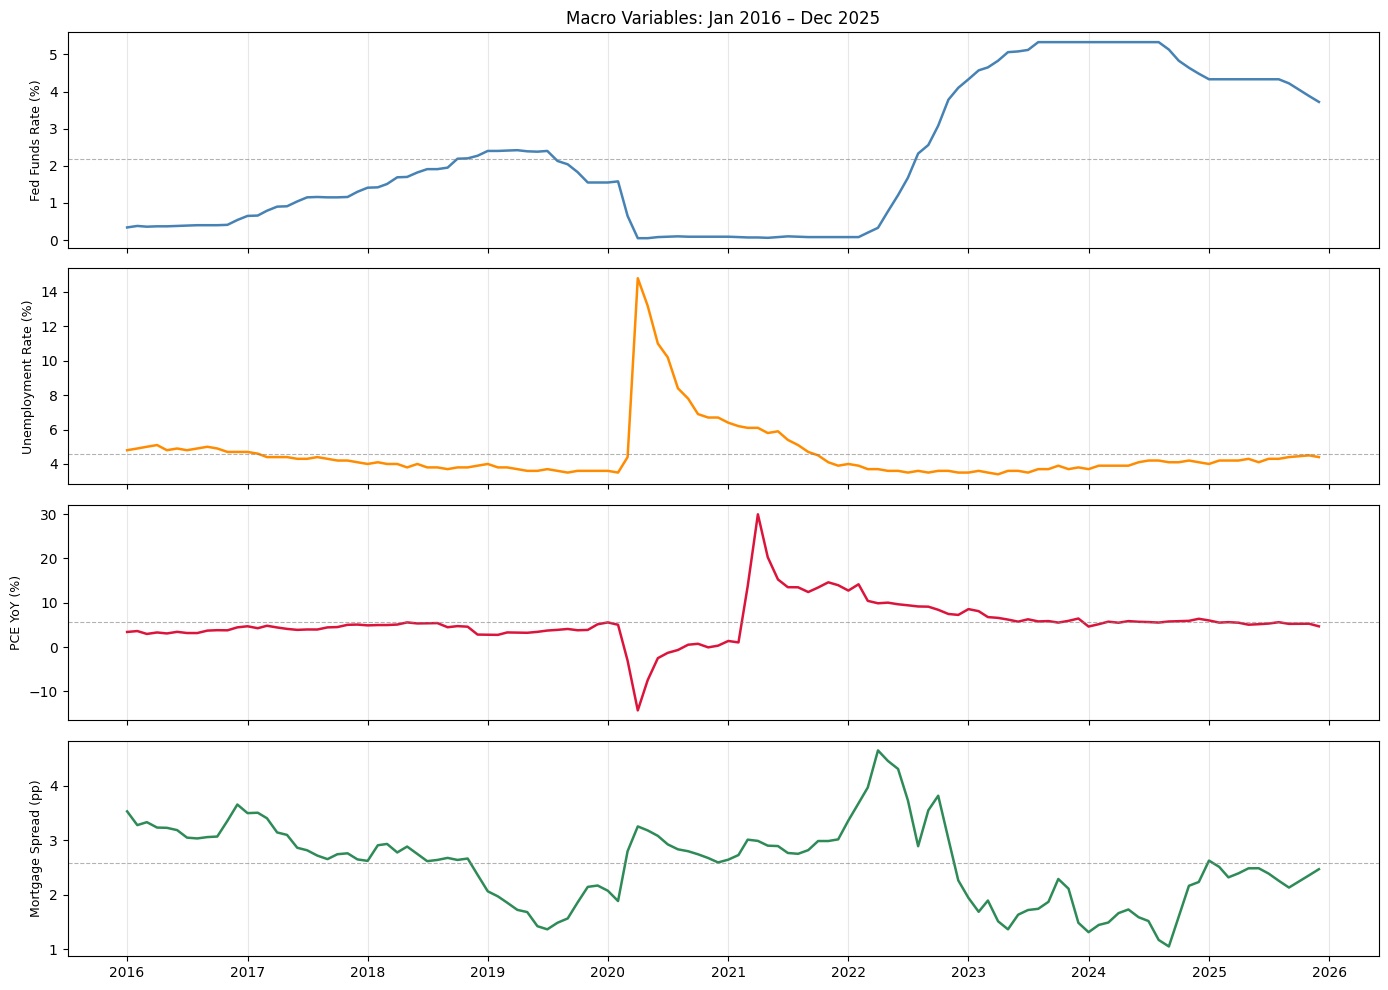

In [2]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

variables = ["FEDFUNDS", "UNRATE", "PCE_YOY", "MORTGAGE_SPREAD"]
colors    = ["steelblue", "darkorange", "crimson", "seagreen"]
labels    = ["Fed Funds Rate (%)", "Unemployment Rate (%)",
             "PCE YoY (%)", "Mortgage Spread (pp)"]

for ax, var, color, label in zip(axes, variables, colors, labels):
    ax.plot(df.index, df[var], color=color, linewidth=1.8)
    ax.set_ylabel(label, fontsize=9)
    ax.axhline(df[var].mean(), color="gray", linestyle="--",
               linewidth=0.8, alpha=0.6)  # mean reference line
    ax.grid(axis="x", alpha=0.3)

axes[0].set_title("Macro Variables: Jan 2016 – Dec 2025", fontsize=12)
plt.tight_layout()
plt.savefig("macro_overview.png", dpi=150)
plt.show()

## Scale and Select K

In [3]:
from sklearn.preprocessing import StandardScaler

features = ["FEDFUNDS", "UNRATE", "PCE_YOY", "MORTGAGE_SPREAD"]

scaler = StandardScaler()
X = scaler.fit_transform(df[features])

# Wrap back into a DataFrame for readability
X_scaled = pd.DataFrame(X, index=df.index, columns=features)
print(X_scaled.describe().round(2))  # All means ~0, stds ~1

       FEDFUNDS  UNRATE  PCE_YOY  MORTGAGE_SPREAD
count    119.00  119.00   119.00           119.00
mean      -0.00    0.00     0.00            -0.00
std        1.00    1.00     1.00             1.00
min       -1.11   -0.69    -4.16            -2.10
25%       -0.94   -0.51    -0.38            -0.77
50%       -0.26   -0.28    -0.09             0.13
75%        1.13    0.07     0.11             0.61
max        1.65    5.93     5.11             2.86


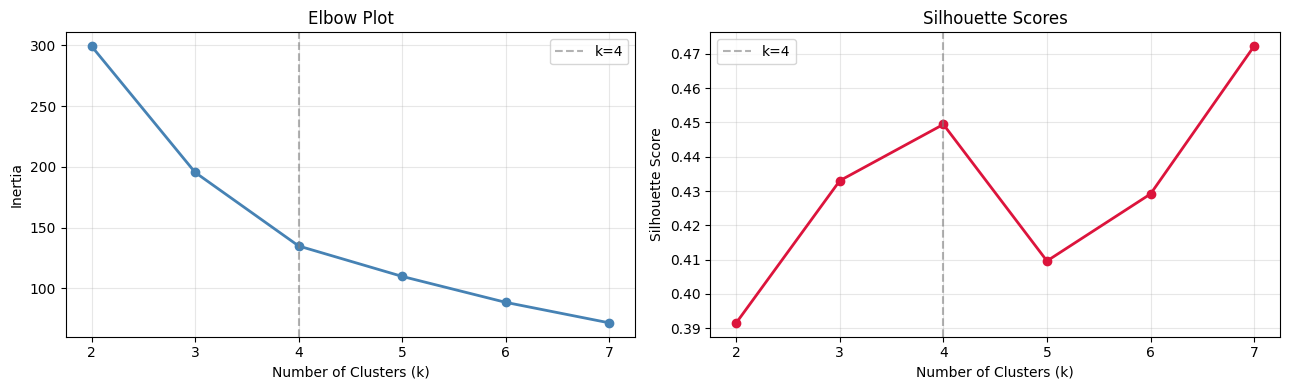


k           Inertia   Silhouette
--------------------------------
2            299.25       0.3916
3            195.42       0.4330
4            134.87       0.4494
5            109.83       0.4096
6             88.49       0.4291
7             71.62       0.4722


In [4]:
# elbow and silhouette tests
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

inertia     = []
silhouettes = []
k_range     = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    inertia.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Elbow
ax1.plot(k_range, inertia, marker="o", color="steelblue", linewidth=2)
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia")
ax1.set_title("Elbow Plot")
ax1.grid(alpha=0.3)

# Silhouette
ax2.plot(k_range, silhouettes, marker="o", color="crimson", linewidth=2)
ax2.set_xlabel("Number of Clusters (k)")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Scores")
ax2.grid(alpha=0.3)

# Mark k=4 on both
ax1.axvline(4, color="gray", linestyle="--", alpha=0.6, label="k=4")
ax2.axvline(4, color="gray", linestyle="--", alpha=0.6, label="k=4")
ax1.legend()
ax2.legend()

plt.tight_layout()
plt.savefig("k_selection.png", dpi=150)
plt.show()

# Print scores table
print(f"\n{'k':<6} {'Inertia':>12} {'Silhouette':>12}")
print("-" * 32)
for k, inn, sil in zip(k_range, inertia, silhouettes):
    print(f"{k:<6} {inn:>12.2f} {sil:>12.4f}")

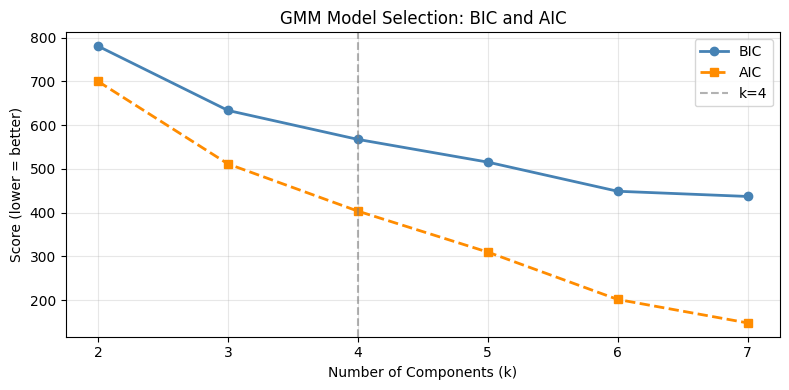


k               BIC          AIC
--------------------------------
2            780.48       699.89
3            633.53       511.25
4            567.35       403.38
5            515.42       309.76
6            448.83       201.48
7            436.93       147.90


In [5]:
from sklearn.mixture import GaussianMixture

bic_scores = []
aic_scores = []

for k in k_range:
    gmm = GaussianMixture(n_components=k, covariance_type="full",
                          random_state=42, n_init=20)
    gmm.fit(X_scaled)
    bic_scores.append(gmm.bic(X_scaled))
    aic_scores.append(gmm.aic(X_scaled))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_range, bic_scores, marker="o", color="steelblue",
        linewidth=2, label="BIC")
ax.plot(k_range, aic_scores, marker="s", color="darkorange",
        linewidth=2, label="AIC", linestyle="--")
ax.axvline(4, color="gray", linestyle="--", alpha=0.6, label="k=4")
ax.set_xlabel("Number of Components (k)")
ax.set_ylabel("Score (lower = better)")
ax.set_title("GMM Model Selection: BIC and AIC")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("gmm_selection.png", dpi=150)
plt.show()

# Print table
print(f"\n{'k':<6} {'BIC':>12} {'AIC':>12}")
print("-" * 32)
for k, bic, aic in zip(k_range, bic_scores, aic_scores):
    print(f"{k:<6} {bic:>12.2f} {aic:>12.2f}")

In [6]:
from sklearn.metrics import adjusted_rand_score

# Fit final models at chosen k
k = 4

km_final = KMeans(n_clusters=k, random_state=42, n_init=20)
km_labels = km_final.fit_predict(X_scaled)

gmm_final = GaussianMixture(n_components=k, covariance_type="full",
                             random_state=42, n_init=20)
gmm_final.fit(X_scaled)
gmm_labels = gmm_final.predict(X_scaled)

# Agreement between the two models
ari = adjusted_rand_score(km_labels, gmm_labels)
print(f"Adjusted Rand Index (KMeans vs GMM): {ari:.4f}")
# Score near 1.0 = both models agree on regime structure
# Score near 0.0 = models disagree, GMM's softer boundaries matter more

Adjusted Rand Index (KMeans vs GMM): 0.6011


In [7]:
import numpy as np
import pandas as pd

k = 4

gmm_final = GaussianMixture(
    n_components=k,
    covariance_type="full",
    random_state=42,
    n_init=20
)
gmm_final.fit(X_scaled)

# Hard labels and soft probabilities
gmm_labels = gmm_final.predict(X_scaled)
gmm_probs  = gmm_final.predict_proba(X_scaled)  # shape (120, 4)

# Attach to your original dataframe
df["regime"] = gmm_labels

prob_cols = [f"prob_regime_{i}" for i in range(k)]
df[prob_cols] = gmm_probs

print(df[["regime"] + prob_cols].head(10))
print("\nRegime counts:")
print(df["regime"].value_counts().sort_index())

                  regime  prob_regime_0  prob_regime_1  prob_regime_2  \
observation_date                                                        
2016-01-01             2       0.002952   8.383846e-34       0.997048   
2016-02-01             2       0.001059   5.150113e-34       0.998941   
2016-03-01             2       0.000990   3.246588e-36       0.999010   
2016-04-01             2       0.002536   8.847010e-34       0.997464   
2016-05-01             2       0.003036   6.841783e-39       0.996964   
2016-06-01             2       0.001290   5.269524e-36       0.998710   
2016-07-01             2       0.002260   2.833139e-40       0.997740   
2016-08-01             2       0.001972   5.242153e-39       0.998028   
2016-09-01             2       0.010907   1.104577e-33       0.989093   
2016-10-01             2       0.004266   1.461587e-34       0.995734   

                  prob_regime_3  
observation_date                 
2016-01-01                  0.0  
2016-02-01           

In [8]:
# Compute mean of original (unscaled) variables per cluster
regime_profiles = df.groupby("regime")[
    ["FEDFUNDS", "UNRATE", "PCE_YOY", "MORTGAGE_SPREAD"]
].mean().round(3)

print(regime_profiles)

        FEDFUNDS  UNRATE  PCE_YOY  MORTGAGE_SPREAD
regime                                            
0          0.655   4.414   12.408            3.351
1          4.766   3.941    5.921            1.944
2          1.355   4.174    4.142            2.653
3          0.082   8.936   -2.023            2.861


In [10]:
# Fill this in after reading regime_profiles output
regime_names = {
    3: "COVID Shock",
    0: "Inflation Surge",
    2: "Expansion / Normalization",
    1: "Aggressive Tightening"
}

df["regime_name"] = df["regime"].map(regime_names)

# Verify counts
print(df["regime_name"].value_counts())

regime_name
Expansion / Normalization    50
Aggressive Tightening        37
Inflation Surge              21
COVID Shock                  11
Name: count, dtype: int64


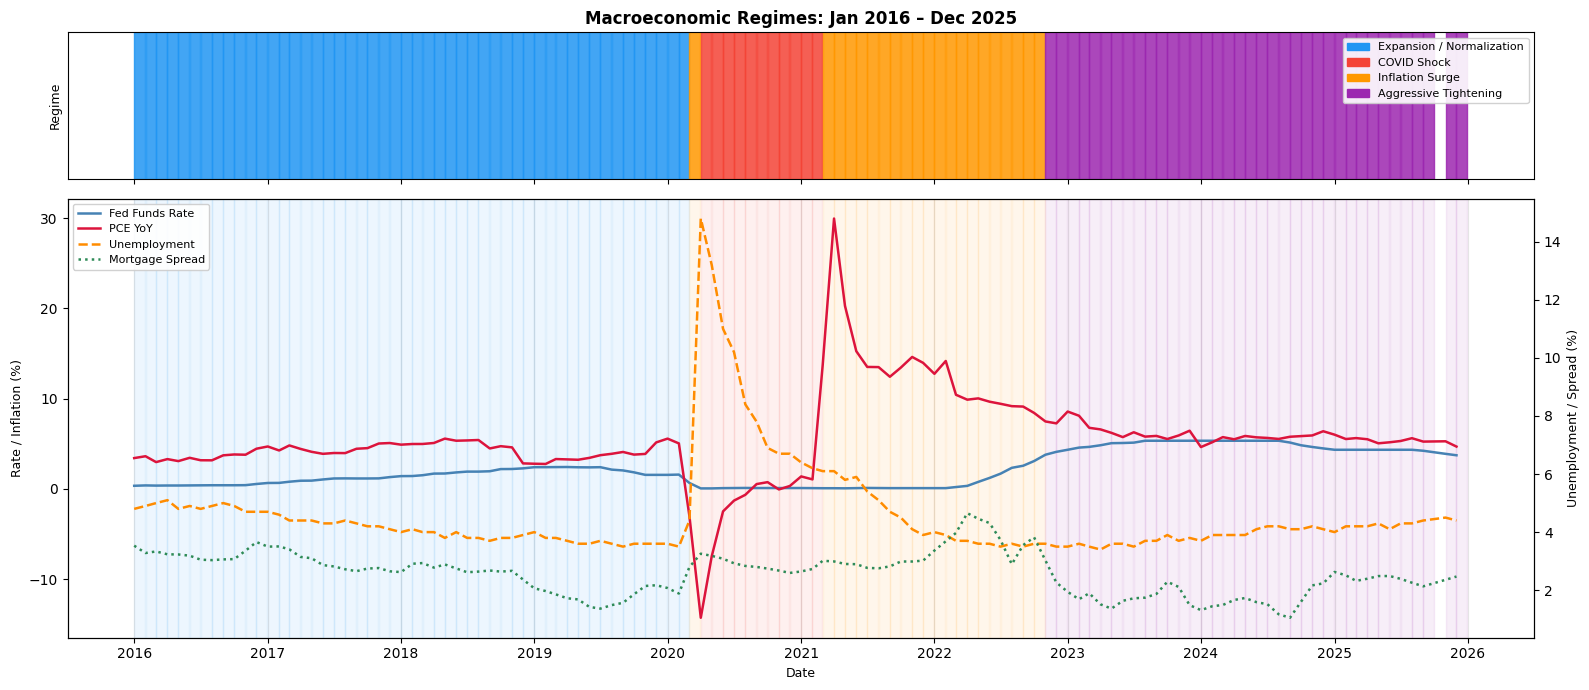

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd
import numpy as np

# Color map for the four regimes
regime_colors = {
    "Expansion / Normalization": "#2196F3",   # blue
    "COVID Shock":               "#F44336",   # red
    "Inflation Surge":           "#FF9800",   # orange
    "Aggressive Tightening":     "#9C27B0"    # purple
}

fig, (ax_regime, ax_vars) = plt.subplots(
    2, 1, figsize=(16, 7),
    gridspec_kw={"height_ratios": [1, 3]},
    sharex=True
)

# --- Top panel: regime color band ---
for i, (date, row) in enumerate(df.iterrows()):
    color = regime_colors[row["regime_name"]]
    ax_regime.axvspan(
        date, date + pd.offsets.MonthEnd(1),
        color=color, alpha=0.85
    )

ax_regime.set_yticks([])
ax_regime.set_ylabel("Regime", fontsize=9)
ax_regime.set_title(
    "Macroeconomic Regimes: Jan 2016 – Dec 2025",
    fontsize=12, fontweight="bold"
)

# Legend
patches = [
    mpatches.Patch(color=c, label=r)
    for r, c in regime_colors.items()
]
ax_regime.legend(
    handles=patches, loc="upper right",
    fontsize=8, framealpha=0.9
)

# --- Bottom panel: macro variables ---
ax2 = ax_vars.twinx()

ax_vars.plot(df.index, df["FEDFUNDS"],
             color="steelblue", linewidth=1.8, label="Fed Funds Rate")
ax_vars.plot(df.index, df["PCE_YOY"],
             color="crimson",   linewidth=1.8, label="PCE YoY")
ax2.plot(df.index, df["UNRATE"],
         color="darkorange", linewidth=1.8,
         linestyle="--", label="Unemployment")
ax2.plot(df.index, df["MORTGAGE_SPREAD"],
         color="seagreen", linewidth=1.8,
         linestyle=":", label="Mortgage Spread")

# Shade regime background on bottom panel too
for i, (date, row) in enumerate(df.iterrows()):
    color = regime_colors[row["regime_name"]]
    ax_vars.axvspan(
        date, date + pd.offsets.MonthEnd(1),
        color=color, alpha=0.08
    )

ax_vars.set_ylabel("Rate / Inflation (%)", fontsize=9)
ax2.set_ylabel("Unemployment / Spread (%)", fontsize=9)
ax_vars.set_xlabel("Date", fontsize=9)

# Combine legends from both axes
lines1, labels1 = ax_vars.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax_vars.legend(
    lines1 + lines2, labels1 + labels2,
    loc="upper left", fontsize=8, framealpha=0.9
)

ax_vars.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("regime_timeline.png", dpi=150)
plt.show()

In [12]:
# Identify every month where regime changed from prior month
df["regime_shift"] = df["regime_name"] != df["regime_name"].shift(1)

transitions = df[df["regime_shift"]].copy()
transitions["from_regime"] = df["regime_name"].shift(1)
transitions = transitions.rename(columns={"regime_name": "to_regime"})
transitions = transitions[["from_regime", "to_regime"]].iloc[1:]  # drop first row (no prior)

print("=" * 65)
print("Regime Transition Dates")
print("=" * 65)
print(f"{'Date':<15} {'From':<28} {'To':<28}")
print("-" * 65)
for date, row in transitions.iterrows():
    print(f"{str(date.date()):<15} {row['from_regime']:<28} {row['to_regime']:<28}")
print("=" * 65)
print(f"\nTotal transitions identified: {len(transitions)}")

Regime Transition Dates
Date            From                         To                          
-----------------------------------------------------------------
2020-03-01      Expansion / Normalization    Inflation Surge             
2020-04-01      Inflation Surge              COVID Shock                 
2021-03-01      COVID Shock                  Inflation Surge             
2022-11-01      Inflation Surge              Aggressive Tightening       

Total transitions identified: 4


## Transition Confidence Using GMM Probabilities
### This is the step that separates your analysis from a standard clustering exercise. For each transition month, you can report how confident the GMM was — a sharp transition shows near-zero probability for the exiting regime, a gradual one shows mixed probabilities.


In [13]:
prob_cols = [f"prob_regime_{i}" for i in range(4)]

print("\nGMM Probability Mass at Transition Months")
print("=" * 75)
print(f"{'Date':<12} {'COVID':>10} {'Inflation':>12} "
      f"{'Expansion':>12} {'Tightening':>12}  {'Dominant':<25}")

# Map regime numbers to names for column headers
regime_num_to_name = {v: k for k, v in {
    "COVID Shock":               3,
    "Inflation Surge":           0,
    "Expansion / Normalization": 2,
    "Aggressive Tightening":     1
}.items()}

print("-" * 75)
for date, row in transitions.iterrows():
    probs = df.loc[date, prob_cols].values
    dominant = df.loc[date, "regime_name"]
    print(
        f"{str(date.date()):<12} "
        f"{probs[3]:>10.3f} "   # COVID Shock = cluster 3
        f"{probs[0]:>12.3f} "   # Inflation Surge = cluster 0
        f"{probs[2]:>12.3f} "   # Expansion = cluster 2
        f"{probs[1]:>12.3f}  "  # Tightening = cluster 1
        f"{dominant:<25}"
    )
print("=" * 75)


GMM Probability Mass at Transition Months
Date              COVID    Inflation    Expansion   Tightening  Dominant                 
---------------------------------------------------------------------------
2020-03-01        0.000        1.000        0.000        0.000  Inflation Surge          
2020-04-01        1.000        0.000        0.000        0.000  COVID Shock              
2021-03-01        0.000        1.000        0.000        0.000  Inflation Surge          
2022-11-01        0.000        0.001        0.000        0.999  Aggressive Tightening    


In [14]:
# Check no further transition appears through December 2025
print(df.loc["2024-01-01":, ["regime_name"]].value_counts())
print(df.loc["2024-01-01":, ["regime_name", "FEDFUNDS"]].head(24))

regime_name          
Aggressive Tightening    23
Name: count, dtype: int64
                            regime_name  FEDFUNDS
observation_date                                 
2024-01-01        Aggressive Tightening      5.33
2024-02-01        Aggressive Tightening      5.33
2024-03-01        Aggressive Tightening      5.33
2024-04-01        Aggressive Tightening      5.33
2024-05-01        Aggressive Tightening      5.33
2024-06-01        Aggressive Tightening      5.33
2024-07-01        Aggressive Tightening      5.33
2024-08-01        Aggressive Tightening      5.33
2024-09-01        Aggressive Tightening      5.13
2024-10-01        Aggressive Tightening      4.83
2024-11-01        Aggressive Tightening      4.64
2024-12-01        Aggressive Tightening      4.48
2025-01-01        Aggressive Tightening      4.33
2025-02-01        Aggressive Tightening      4.33
2025-03-01        Aggressive Tightening      4.33
2025-04-01        Aggressive Tightening      4.33
2025-05-01        Aggres

In [15]:
# Collapse March 2020 into COVID Shock
df.loc["2020-03-01", "regime_name"] = "COVID Shock"
df.loc["2020-03-01", "regime"]      = 3

# Verify the correction
print(df.loc["2020-01-01":"2020-06-01",
             ["regime", "regime_name", "FEDFUNDS", "UNRATE", "PCE_YOY"]])

                  regime                regime_name  FEDFUNDS  UNRATE  \
observation_date                                                        
2020-01-01             2  Expansion / Normalization      1.55     3.6   
2020-02-01             2  Expansion / Normalization      1.58     3.5   
2020-03-01             3                COVID Shock      0.65     4.4   
2020-04-01             3                COVID Shock      0.05    14.8   
2020-05-01             3                COVID Shock      0.05    13.2   
2020-06-01             3                COVID Shock      0.08    11.0   

                    PCE_YOY  
observation_date             
2020-01-01         5.564233  
2020-02-01         5.034213  
2020-03-01        -3.058546  
2020-04-01       -14.281316  
2020-05-01        -7.467272  
2020-06-01        -2.495020  


In [16]:
df.to_csv("macro_regimes_final.csv")

print("Regime distribution after correction:")
print(df["regime_name"].value_counts().sort_index())
print(f"\nDate range: {df.index.min().date()} → {df.index.max().date()}")

Regime distribution after correction:
regime_name
Aggressive Tightening        37
COVID Shock                  12
Expansion / Normalization    50
Inflation Surge              20
Name: count, dtype: int64

Date range: 2016-01-01 → 2025-12-01
